# 딥러닝 산출물 — AI 기반 반도체 웨이퍼 결함 패턴 분류 모델 개발 및 시각화
**기법:** CNN (Convolutional Neural Network) · **데이터:** WM-811K Wafer Map Dataset

---
### 프로젝트 개요
- 반도체 양산 공정에서 웨이퍼맵(wafer map)에 나타나는 **불량 die의 공간적 패턴**(Center, Donut, Edge-Ring, Scratch 등)은
  특정 공정 이슈와 직결됨 → 패턴을 자동 분류하면 **수율·품질 이상의 근본원인을 조기에 식별** 가능
- 기존엔 엔지니어가 육안으로 웨이퍼맵을 판독 → 시간 소요·주관 개입 → **CNN 기반 자동 분류로 Smart Manufacturing 구현**
- 본 노트북은 학원 과정의 **꽃 이미지 CNN 분류 예제**와 동일한 구조(Conv2D→MaxPooling→Dropout→Flatten→Dense)를
  웨이퍼맵(1채널 이미지)에 맞게 확장한 것임

> **데이터 안내 (중요)**
> WM-811K 원본(`LSWMD.pkl`, 약 2GB)은 Kaggle에서 받아야 함:
> https://www.kaggle.com/datasets/qingyi/wm811k-wafer-map → `LSWMD.pkl` 다운로드 후 이 노트북과 같은 폴더에 둘 것.
> 다운로드 전에 코드 점검하고 싶으면 아래 `USE_SYNTHETIC = True` 로 두면 합성 웨이퍼맵으로 전체 파이프라인이 그대로 돌아감.
> **제출용 산출물은 반드시 `USE_SYNTHETIC = False` (실제 WM-811K)로 학습한 결과를 사용할 것.**

## 1. 라이브러리 import 및 기본 설정

In [1]:
# 사전 설치: pip install tensorflow scikit-learn seaborn opencv-python joblib
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2  # 웨이퍼맵 리사이즈 (값 보존을 위해 최근접 보간 사용)
import joblib  # 라벨인코더 저장 (머신러닝 산출물과 동일 방식)
import tensorflow as tf
import mlflow            # 실험 추적/비교
import mlflow.keras
import mlflow.tensorflow
from tensorflow.keras import layers
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# 재현성을 위한 시드 고정
np.random.seed(42)
tf.random.set_seed(42)

# 한글 폰트 (그래프 깨짐 방지) - 환경에 맞게 선택
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print('TensorFlow 버전:', tf.__version__)

TensorFlow 버전: 2.21.0


## 2. 설정값 정의
웨이퍼맵 값 규칙: **0 = 웨이퍼 밖 / 1 = 정상 die / 2 = 불량 die**

In [4]:
USE_SYNTHETIC = False   # True: 합성 데이터로 파이프라인 점검 / False: 실제 WM-811K(LSWMD.pkl) 사용 (제출용)
PKL_PATH = 'LSWMD.pkl' # Kaggle에서 받은 원본 경로
IMG_SIZE = 128  # 96→128: Loc/Edge-Loc 가장자리 디테일 최대한 살리기
BATCH_SIZE = 32   # GPU 활용, 학습 속도
EPOCHS = 30   # 상한만 크게, EarlyStopping이 알아서 멈춤

# ── 데이터 사용 전략 ──
USE_ALL_LABELED = True   # True: 라벨 있는 행 전부 사용(데이터 안 버림, 권장) / False: 클래스별 샘플링
SAMPLES_PER_CLASS = 1000 # USE_ALL_LABELED=False 일 때만 적용 (클래스별 최대 표본 수)
CAP_NONE = 10000         # 'none'을 2만으로 상한(결함 8종은 전부 유지). none 누수↓ + 메모리↓. 전체 쓰려면 None

# ── 불균형 처리: Focal Loss ──
# gamma가 클수록 '맞히기 쉬운 다수 클래스'의 손실을 더 깎아 → 드문 결함에 집중
FOCAL_GAMMA = 3.0   # 2.0→3.0: 극소수 클래스(Near-full 등)에 더 집중

## 2-1. MLflow 실험 추적 설정
설정/기법을 바꿀 때마다 **파라미터·Macro-F1·클래스별 recall·혼동행렬**을 자동 기록해 실험을 비교합니다.
- UI 확인:  터미널에서 `mlflow ui --backend-store-uri sqlite:///mlflow.db`  →  http://localhost:5000
- (사전 설치: `pip install mlflow`)

In [5]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Wafer_Defect_CNN_Comparison")

# run 이름에 핵심 설정을 담아 실험 간 비교가 쉽게
RUN_NAME = f"img{IMG_SIZE}_gamma{FOCAL_GAMMA}_cap{CAP_NONE}_batch{BATCH_SIZE}"
print("MLflow run name:", RUN_NAME)

MLflow run name: img128_gamma3.0_cap10000_batch32


## 3. 데이터 준비

### 3-A. (제출용) 실제 WM-811K 로드 & 전처리
`USE_SYNTHETIC = False` 일 때 실행됨. LSWMD.pkl에서 라벨이 있는 결함 패턴만 추출하고, 클래스별로 표본 수를 맞춰 불균형을 완화함.

In [6]:
def load_real_wm811k(pkl_path=PKL_PATH):
    # 원본 pickle 로드 (pandas DataFrame)
    df = pd.read_pickle(pkl_path)

    # failureType 컬럼은 중첩 배열 형태 → 문자열 라벨로 변환
    def extract_label(x):
        try:
            if isinstance(x, np.ndarray) and x.size > 0:
                return str(x[0][0])
            if isinstance(x, str) and len(x) > 0:
                return x
        except Exception:
            pass
        return 'unlabeled'   # 빈 칸 = 미검토(정상 아님!) → 학습 제외
    df['label'] = df['failureType'].apply(extract_label)

    # 라벨이 있는 행만 사용 ('unlabeled', '' 제거)
    df = df[~df['label'].isin(['unlabeled', ''])].reset_index(drop=True)

    if USE_ALL_LABELED:
        # 라벨 있는 행 전부 사용 (데이터 안 버림)
        # 단, 'none'이 압도적으로 많아 느리면 CAP_NONE으로 정상 클래스만 상한
        if CAP_NONE is not None:
            none_df = df[df['label'] == 'none'].sample(n=min(CAP_NONE, (df['label']=='none').sum()), random_state=42)
            df = pd.concat([df[df['label'] != 'none'], none_df]).reset_index(drop=True)
    else:
        # 클래스별 표본 수 균형 맞추기 (언더샘플링)
        balanced = []
        for cls, grp in df.groupby('label'):
            n = min(len(grp), SAMPLES_PER_CLASS)
            balanced.append(grp.sample(n=n, random_state=42))
        df = pd.concat(balanced).reset_index(drop=True)

    print('클래스별 사용 수:')
    print(df['label'].value_counts())

    # 웨이퍼맵을 64x64로 리사이즈 (값 0/1/2 보존을 위해 최근접 보간)
    # 메모리 절약을 위해 uint8로 저장 (모델의 Rescaling에서 float로 변환됨)
    X = []
    for wm in df['waferMap']:
        arr = np.asarray(wm, dtype='float32')
        arr = cv2.resize(arr, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
        X.append(arr.astype('uint8'))
    X = np.array(X)[..., np.newaxis]  # (N, 64, 64, 1)
    y = df['label'].values
    return X, y

if not USE_SYNTHETIC:
    X, y_str = load_real_wm811k()
    print('실제 WM-811K 로드 완료:', X.shape)

클래스별 사용 수:
label
none         10000
Edge-Ring     9680
Edge-Loc      5189
Center        4294
Loc           3593
Scratch       1193
Random         866
Donut          555
Near-full      149
Name: count, dtype: int64
실제 WM-811K 로드 완료: (35519, 128, 128, 1)


### 3-B. (점검용) 합성 웨이퍼맵 생성
`USE_SYNTHETIC = True` 일 때 실행됨. 실제 데이터 받기 전 코드가 정상 동작하는지 확인하는 용도.

In [ ]:
def make_base_wafer(size=IMG_SIZE):
    yy, xx = np.ogrid[:size, :size]
    c = size / 2
    inside = (yy - c) ** 2 + (xx - c) ** 2 <= (c - 1) ** 2
    m = np.zeros((size, size), dtype='float32')
    m[inside] = 1  # 정상 die
    return m, inside

def make_synthetic(pattern):
    m, inside = make_base_wafer()
    yy, xx = np.ogrid[:IMG_SIZE, :IMG_SIZE]
    c = IMG_SIZE / 2
    d = (yy - c) ** 2 + (xx - c) ** 2
    if pattern == 'Center':
        m[(d <= (IMG_SIZE * 0.18) ** 2) & inside] = 2
    elif pattern == 'Donut':
        m[(d <= (IMG_SIZE * 0.38) ** 2) & (d >= (IMG_SIZE * 0.25) ** 2) & inside] = 2
    elif pattern == 'Edge-Ring':
        m[(d >= (IMG_SIZE * 0.40) ** 2) & inside] = 2
    elif pattern == 'Scratch':
        k = np.random.randint(-3, 3)
        for x in range(IMG_SIZE):
            yv = int(0.6 * x + k + np.random.randint(-1, 2))
            if 0 <= yv < IMG_SIZE and inside[yv, x]:
                m[yv, x] = 2
    elif pattern == 'Loc':
        cx, cy = np.random.randint(15, 50, 2)
        m[((yy - cy) ** 2 + (xx - cx) ** 2 <= (IMG_SIZE * 0.10) ** 2) & inside] = 2
    # 'none' = 결함 없음
    return m

if USE_SYNTHETIC:
    classes = ['Center', 'Donut', 'Edge-Ring', 'Scratch', 'Loc', 'none']
    X, y_str = [], []
    for cls in classes:
        for _ in range(300):
            X.append(make_synthetic(cls)); y_str.append(cls)
    X = np.array(X)[..., np.newaxis].astype('float32')
    y_str = np.array(y_str)
    print('합성 데이터 생성 완료:', X.shape)

## 4. 탐색적 데이터 분석 (EDA)
### 4-1. 클래스 분포 확인

none         10000
Edge-Ring     9680
Edge-Loc      5189
Center        4294
Loc           3593
Scratch       1193
Random         866
Donut          555
Near-full      149
Name: count, dtype: int64


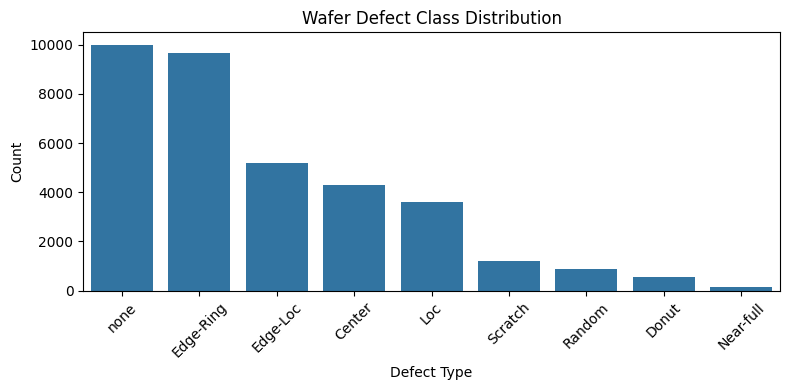

In [7]:
counts = pd.Series(y_str).value_counts()
print(counts)

plt.figure(figsize=(8, 4))
sns.barplot(x=counts.index, y=counts.values)
plt.title('Wafer Defect Class Distribution')
plt.ylabel('Count'); plt.xlabel('Defect Type')
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

### 4-2. 클래스별 샘플 웨이퍼맵 시각화

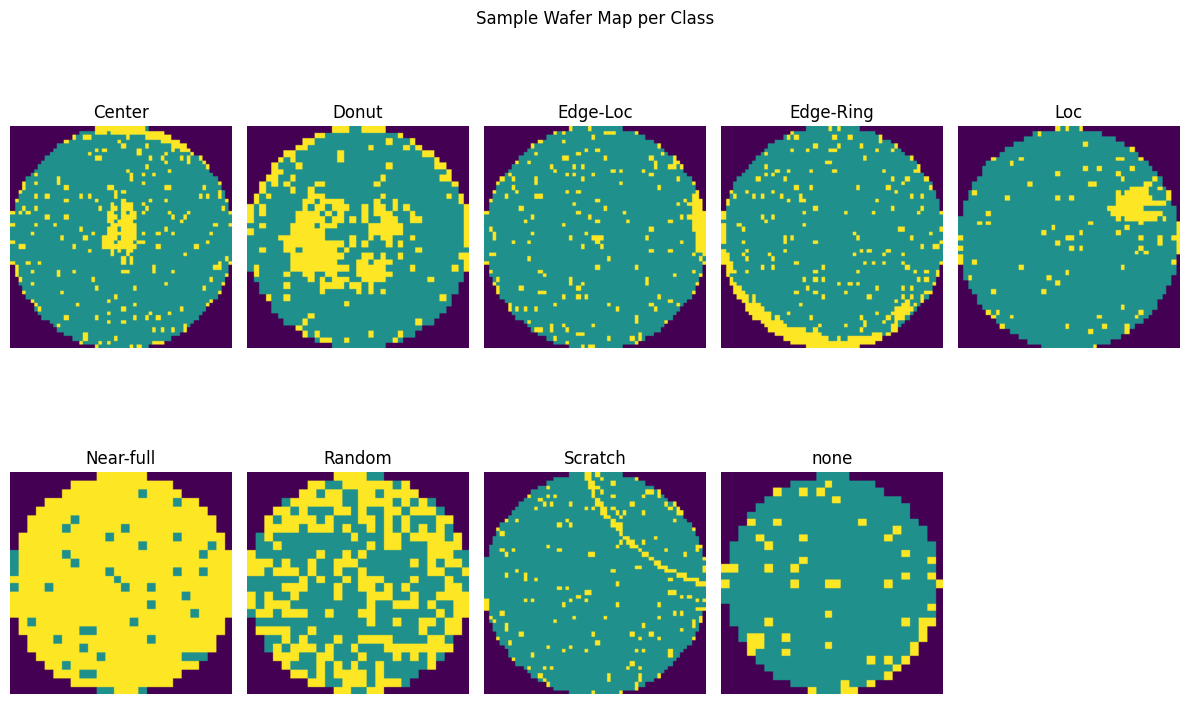

In [8]:
unique_cls = sorted(pd.unique(y_str))
plt.figure(figsize=(12, 8))
for i, cls in enumerate(unique_cls):
    idx = np.where(y_str == cls)[0][0]
    plt.subplot(2, (len(unique_cls) + 1) // 2, i + 1)
    plt.imshow(X[idx, :, :, 0], cmap='viridis')  # 0=밖,1=정상,2=불량
    plt.title(cls); plt.axis('off')
plt.suptitle('Sample Wafer Map per Class')
plt.tight_layout(); plt.show()

## 5. 전처리
- 라벨을 정수로 인코딩 (`LabelEncoder`) — 머신러닝 산출물과 동일 방식
- 학습/테스트 분리 (`stratify`로 클래스 비율 유지)

In [9]:
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_int = le.fit_transform(y_str)        # 정수 라벨 (0,1,2,...)
num_classes = len(le.classes_)
print('클래스:', list(le.classes_))

    # Focal Loss(CategoricalFocalCrossentropy)는 원-핫 라벨이 필요
y = to_categorical(y_int, num_classes)

# stratify는 정수 라벨로 (클래스 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y_int, random_state=42
)
print('학습:', X_train.shape, '/ 테스트:', X_test.shape)

클래스: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']
학습: (28415, 128, 128, 1) / 테스트: (7104, 128, 128, 1)


## 6. CNN 모델 구성
학원 **꽃 이미지 CNN 예제와 동일 구조**. 입력만 3채널 RGB → 1채널 웨이퍼맵으로 변경.
- 데이터 증강(RandomFlip/Rotation)으로 과적합 완화
- `Rescaling(1./2.)` 로 0/1/2 값을 0~1 범위로 정규화 (웨이퍼맵 최댓값이 2이므로)

In [12]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

model = tf.keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./2., input_shape=(IMG_SIZE, IMG_SIZE, 1)),  # 0/1/2 → 0~1
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu', name='last_conv'),   # ★ Grad-CAM 추적 대상 (이름 지정)
    layers.MaxPooling2D(),
    layers.Dropout(0.3),                                        # 0.2→0.3: 레이어 늘어난 만큼 과적합 방지 강화
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    # ★ Focal Loss: 다수 클래스(none)의 쉬운 샘플 손실을 깎아 드문 결함에 집중 → 불균형 보정
    loss=tf.keras.losses.CategoricalFocalCrossentropy(gamma=FOCAL_GAMMA),
    metrics=['accuracy']
)

## 7. 모델 학습 (Early Stopping 적용)

In [13]:
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix, classification_report
import seaborn as sns

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

with mlflow.start_run(run_name=RUN_NAME):
    # ── 파라미터 로깅 ──
    mlflow.log_param("img_size", IMG_SIZE)
    mlflow.log_param("batch_size", BATCH_SIZE)
    mlflow.log_param("epochs_max", EPOCHS)
    mlflow.log_param("focal_gamma", FOCAL_GAMMA)
    mlflow.log_param("cap_none", str(CAP_NONE))
    mlflow.log_param("use_all_labeled", USE_ALL_LABELED)
    mlflow.log_param("num_classes", num_classes)
    mlflow.log_param("architecture", "Conv16-32-64-128 + Dense128")
    mlflow.log_param("loss", "CategoricalFocalCrossentropy")

    # ── 학습 ──
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks
    )

    # ── epoch별 메트릭 로깅 ──
    for ep, v in enumerate(history.history['loss']):         mlflow.log_metric("train_loss", v, step=ep)
    for ep, v in enumerate(history.history['val_loss']):     mlflow.log_metric("val_loss", v, step=ep)
    for ep, v in enumerate(history.history['accuracy']):     mlflow.log_metric("train_accuracy", v, step=ep)
    for ep, v in enumerate(history.history['val_accuracy']): mlflow.log_metric("val_accuracy", v, step=ep)

    # ── 평가 ──
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    y_true = y_test.argmax(axis=1)
    y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    macro_f1 = f1_score(y_true, y_pred, average='macro')

    # ── 핵심 지표 로깅 (불균형 데이터라 accuracy보다 macro_f1·recall이 중요) ──
    mlflow.log_metric("test_accuracy", test_acc)
    mlflow.log_metric("macro_f1", macro_f1)
    for cls_name, r in zip(le.classes_, recall_score(y_true, y_pred, average=None, zero_division=0)):
        mlflow.log_metric(f"recall_{cls_name}", r)        # 결함별 누락(miss) 추적
    # precision: 정상을 결함으로 오판(false alarm) 추적
    for cls_name, pr in zip(le.classes_, precision_score(y_true, y_pred, average=None, zero_division=0)):
        mlflow.log_metric(f"precision_{cls_name}", pr)
    mlflow.log_metric("macro_precision", precision_score(y_true, y_pred, average='macro', zero_division=0))

    # ── 혼동행렬 이미지 artifact ──
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title('Confusion Matrix'); plt.ylabel('True'); plt.xlabel('Predicted'); plt.tight_layout()
    plt.savefig('confusion_matrix.png'); plt.close()
    mlflow.log_artifact('confusion_matrix.png')

    # ── 분류 리포트 텍스트 artifact ──
    report = classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0)
    with open('classification_report.txt', 'w') as f:
        f.write(report)
    mlflow.log_artifact('classification_report.txt')

    # ── 모델 로깅 (버전 호환 안전장치) ──
    try:
        mlflow.keras.log_model(model, "wafer_cnn_model")
    except Exception:
        try:
            mlflow.tensorflow.log_model(model, "wafer_cnn_model")
        except Exception:
            model.save('wafer_cnn_logged.h5'); mlflow.log_artifact('wafer_cnn_logged.h5')

    print(f"[MLflow] {RUN_NAME} | test_acc={test_acc:.4f} | macro_f1={macro_f1:.4f}")

model.summary()

Epoch 1/30
711/711 ━━━━━━━━━━━━━━━━━━━━ 80s 110ms/step - accuracy: 0.7266 - loss: 0.0900 - val_accuracy: 0.8291 - val_loss: 0.0512
Epoch 2/30
711/711 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.8529 - loss: 0.0387 - val_accuracy: 0.8738 - val_loss: 0.0319
Epoch 3/30
711/711 ━━━━━━━━━━━━━━━━━━━━ 88s 124ms/step - accuracy: 0.8805 - loss: 0.0280 - val_accuracy: 0.8895 - val_loss: 0.0264
Epoch 4/30
711/711 ━━━━━━━━━━━━━━━━━━━━ 90s 126ms/step - accuracy: 0.8912 - loss: 0.0248 - val_accuracy: 0.8969 - val_loss: 0.0259
Epoch 5/30
711/711 ━━━━━━━━━━━━━━━━━━━━ 91s 127ms/step - accuracy: 0.9045 - loss: 0.0215 - val_accuracy: 0.8879 - val_loss: 0.0267
Epoch 6/30
711/711 ━━━━━━━━━━━━━━━━━━━━ 91s 128ms/step - accuracy: 0.9084 - loss: 0.0193 - val_accuracy: 0.9055 - val_loss: 0.0210
Epoch 7/30
711/711 ━━━━━━━━━━━━━━━━━━━━ 91s 128ms/step - accuracy: 0.9136 - loss: 0.0178 - val_accuracy: 0.9115 - val_loss: 0.0206
Epoch 8/30
711/711 ━━━━━━━━━━━━━━━━━━━━ 93s 131ms/step - accuracy: 0.9155 - loss: 0

2026/06/30 16:13:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/30 16:13:07 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


[MLflow] img128_gamma3.0_cap10000_batch32 | test_acc=0.9202 | macro_f1=0.8866


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,441,053 (13.13 MB)

 Trainable params: 1,147,017 (4.38 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,294,036 (8.75 MB)

## 8. 학습 결과 시각화 (정확도 / 손실 곡선)

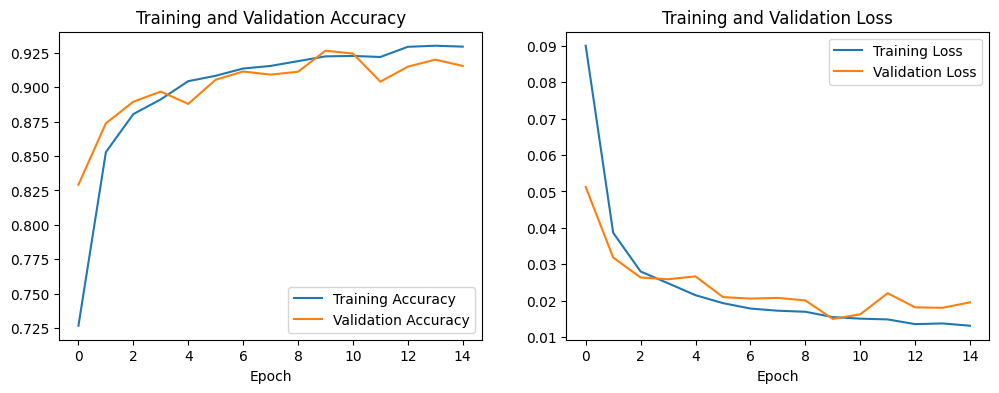

In [14]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy'); plt.xlabel('Epoch'); plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss'); plt.xlabel('Epoch'); plt.legend(loc='upper right')
plt.show()

## 9. 모델 평가
### 9-1. 테스트 정확도 & 분류 리포트

In [15]:
from sklearn.metrics import f1_score

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'테스트 정확도(accuracy): {test_acc:.4f}')

y_true = y_test.argmax(axis=1)              # 원-핫 → 정수
y_pred = model.predict(X_test, verbose=0).argmax(axis=1)

# ※ 불균형 데이터에서는 accuracy보다 recall / Macro-F1이 중요
print(f'Macro-F1 (클래스 공평 평균): {f1_score(y_true, y_pred, average="macro"):.4f}')
print()
print(classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0))

테스트 정확도(accuracy): 0.9202
Macro-F1 (클래스 공평 평균): 0.8866

              precision    recall  f1-score   support

      Center       0.96      0.95      0.96       859
       Donut       0.88      0.82      0.85       111
    Edge-Loc       0.88      0.83      0.85      1038
   Edge-Ring       0.95      0.99      0.97      1936
         Loc       0.82      0.83      0.83       719
   Near-full       1.00      0.80      0.89        30
      Random       0.88      0.94      0.91       173
     Scratch       0.79      0.79      0.79       238
        none       0.95      0.94      0.94      2000

    accuracy                           0.92      7104
   macro avg       0.90      0.88      0.89      7104
weighted avg       0.92      0.92      0.92      7104



### 9-2. 혼동행렬 (Confusion Matrix)

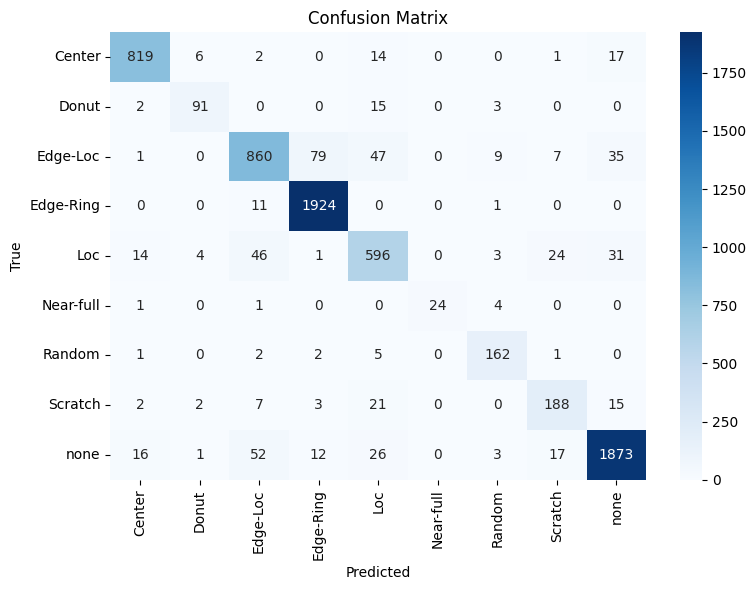

In [16]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix'); plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

## 10. 모델 저장
머신러닝 산출물과 동일하게 **모델(.h5) + 라벨인코더(joblib)** 를 함께 저장 → Streamlit 앱에서 로드.

In [17]:
os.makedirs('model', exist_ok=True)
model.save('model/wafer_cnn_model.h5')
joblib.dump(le, 'model/wafer_label_encoder.pkl')
print('저장 완료: model/wafer_cnn_model.h5, model/wafer_label_encoder.pkl')

저장 완료: model/wafer_cnn_model.h5, model/wafer_label_encoder.pkl


## 11. 예측 함수 (단일 웨이퍼맵)
새 웨이퍼맵 하나를 입력하면 결함 패턴과 확률을 반환.

예측 결함 패턴: Scratch (확률 76.13%) / 실제: Scratch


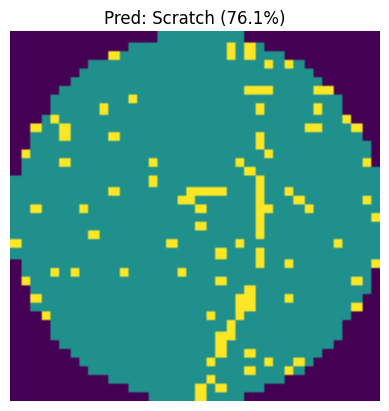

In [18]:
def predict_wafer(wafer_map, model, le):
    arr = np.asarray(wafer_map, dtype='float32')
    if arr.shape != (IMG_SIZE, IMG_SIZE):
        arr = cv2.resize(arr, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    arr = arr[np.newaxis, ..., np.newaxis]
    proba = model.predict(arr, verbose=0)[0]
    cls = le.classes_[proba.argmax()]
    return cls, float(proba.max())

# 예시: 테스트셋 첫 번째 웨이퍼맵 예측
sample = X_test[0, :, :, 0]
pred_cls, conf = predict_wafer(sample, model, le)
print(f'예측 결함 패턴: {pred_cls} (확률 {conf:.2%}) / 실제: {le.classes_[y_test[0].argmax()]}')

plt.imshow(sample, cmap='viridis'); plt.title(f'Pred: {pred_cls} ({conf:.1%})'); plt.axis('off'); plt.show()

## 12. Grad-CAM — 결함 근거 시각화 (XAI)
모델이 **이미지의 어느 부위를 보고** 그 결함으로 판단했는지 히트맵으로 시각화합니다.
- 빨강(JET) = 판단에 크게 기여한 영역
- Scratch면 긁힌 선, Edge-Ring이면 가장자리가 빨갛게 떠야 '제대로 본' 것
- 오분류 케이스에 적용하면 **왜 틀렸는지**를 눈으로 진단 가능 → 설명가능 AI(XAI)
> Grad-CAM은 성능을 올리는 게 아니라, 학습된 모델의 **판단 근거를 설명**하는 도구입니다.

In [19]:
from matplotlib import cm

def build_grad_model(model, last_conv_name='last_conv'):
    """Keras 3 호환: Input부터 레이어를 다시 이어 (마지막 Conv 출력, 최종 출력) 모델 생성"""
    inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    x = inp; conv_out = None
    for layer in model.layers:
        x = layer(x)                       # 학습된 가중치 그대로 공유
        if layer.name == last_conv_name:
            conv_out = x
    return tf.keras.Model(inp, [conv_out, x])

def make_gradcam(img2d, model, last_conv_name='last_conv', pred_index=None):
    """img2d: (IMG,IMG) 웨이퍼맵 → (heatmap, 예측 클래스 index)"""
    arr = img2d[np.newaxis, ..., np.newaxis].astype('float32')
    grad_model = build_grad_model(model, last_conv_name)
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(arr)
        if pred_index is None:
            pred_index = int(tf.argmax(preds[0]))
        class_channel = preds[:, pred_index]      # 해당 클래스 점수
    grads = tape.gradient(class_channel, conv_out)        # gradient 계산
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))        # 채널별 평균 중요도
    heatmap = tf.squeeze(conv_out[0] @ pooled[..., tf.newaxis])  # feature map 가중합
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)  # ReLU + 정규화
    return heatmap.numpy(), pred_index

def overlay_gradcam(wafer2d, heatmap, alpha=0.5):
    """웨이퍼맵 위에 히트맵 오버레이 (원본 RGB + JET 컬러맵 블렌딩)"""
    base = (cm.viridis(wafer2d / 2.0)[:, :, :3] * 255).astype('uint8')
    hm = cv2.resize(heatmap, (wafer2d.shape[1], wafer2d.shape[0]))
    hm = cv2.applyColorMap(np.uint8(255 * hm), cv2.COLORMAP_JET)
    hm = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB)
    return np.clip(base * (1 - alpha) + hm * alpha, 0, 255).astype('uint8')

print("Grad-CAM 함수 준비 완료")

Grad-CAM 함수 준비 완료


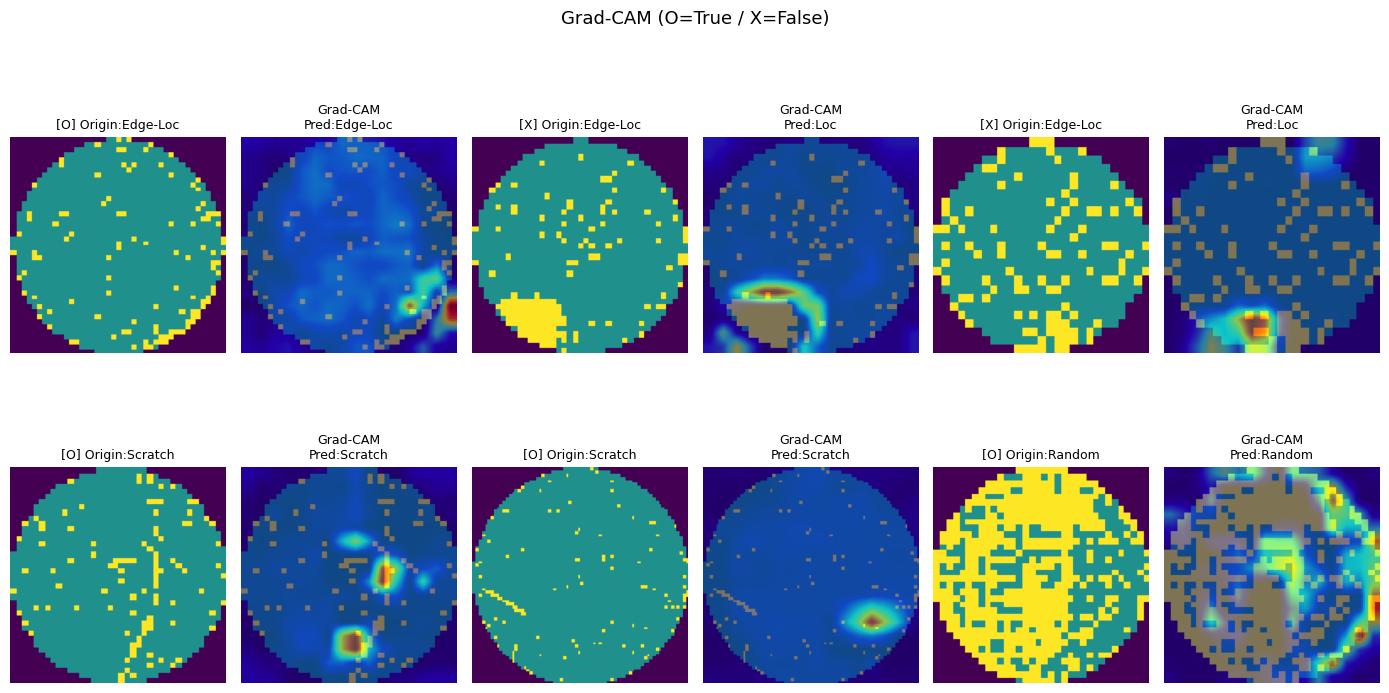

In [21]:
# 오분류 케이스 우선으로 Grad-CAM 시각화 (왜 틀렸는지 진단)
y_true_idx = y_test.argmax(axis=1)
y_pred_idx = model.predict(X_test, verbose=0).argmax(axis=1)

wrong = np.where(y_true_idx != y_pred_idx)[0]
correct = np.where(y_true_idx == y_pred_idx)[0]
# 오분류 3개 + 정분류 3개 (오분류가 적으면 정분류로 채움)
sel = list(wrong[:3]) + list(correct[:3])
sel = sel[:6]

plt.figure(figsize=(14, 8))
for r, idx in enumerate(sel):
    wafer = X_test[idx, :, :, 0].astype('float32')
    hm, pred_i = make_gradcam(wafer, model)
    ov = overlay_gradcam(wafer, hm)
    true_name = le.classes_[y_true_idx[idx]]
    pred_name = le.classes_[pred_i]
    ok = "O" if true_name == pred_name else "X"

    plt.subplot(2, 6, r*2 + 1)
    plt.imshow(wafer, cmap='viridis'); plt.axis('off')
    plt.title(f"[{ok}] Origin:{true_name}", fontsize=9)
    plt.subplot(2, 6, r*2 + 2)
    plt.imshow(ov); plt.axis('off')
    plt.title(f"Grad-CAM\nPred:{pred_name}", fontsize=9)
plt.suptitle("Grad-CAM (O=True / X=False)", fontsize=13)
plt.tight_layout(); plt.show()

## 12-1. (선택) 이미 끝난 run에 precision 덧붙이기
재학습 없이, 기존 run에 precision을 추가하고 싶을 때만 사용. `TARGET_RUN_ID`에 MLflow에서 복사한 run id를 넣으세요.
(이번 학습부터는 위 학습 셀이 precision을 자동 로깅합니다.)

In [ ]:
# 현재 메모리의 y_true, y_pred 기준으로 특정 run에 precision 덧붙이기
# TARGET_RUN_ID = "여기에_run_id_붙여넣기"
# from sklearn.metrics import precision_score
# with mlflow.start_run(run_id=TARGET_RUN_ID):
#     for cls_name, pr in zip(le.classes_, precision_score(y_true, y_pred, average=None, zero_division=0)):
#         mlflow.log_metric(f"precision_{cls_name}", pr)
#     mlflow.log_metric("macro_precision", precision_score(y_true, y_pred, average='macro', zero_division=0))
# print("precision 덧붙이기 완료")

## 13. 결론 및 활용 방안
- 학원 꽃 이미지 CNN 예제 구조를 그대로 활용해 **반도체 웨이퍼 결함 패턴 자동 분류** 모델을 구현
- **Smart Manufacturing 관점:** 웨이퍼맵 패턴은 특정 공정 이상(증착 편차, 에지 척킹 이슈, 파티클 scratch 등)과 매핑됨
  → 자동 분류로 **수율 이상의 근본원인을 조기 식별**, 엔지니어 판독 시간 단축
- **확장:** 패턴별 공정 원인 매핑 테이블, 실시간 FDC 데이터 연계, Digital Twin 기반 가상 검증으로 발전 가능
- Streamlit 앱(`streamlit_wafer.py`)으로 배포 → 엔지니어가 웨이퍼맵 업로드 시 즉시 패턴 진단